## Regresión Lineal

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib. 
%matplotlib inline  
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

#### 0. Importamos los datos 

In [2]:
os.getcwd()

'c:\\Users\\Oscar\\OneDrive - FM4\\Escritorio\\EVOLVE\\Data Science\\EVOLVE\\Tomas_Arteaga_ML\\Notebooks_Clase'

In [3]:
path = '../Datasets/USA_Housing.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path)
df.head(5)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


#### 1. Analizamos los datos

In [4]:
#chequeamos nulos 
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Para este ejemplo, por razones de simplicidad, quitamos la variable direccion (address). Pero esta informacion puede3 ser muy valiosa con el tratamiento adecuado.  

In [5]:
#quito las variable address 
df2 = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population', 'Price' ]]
df2

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


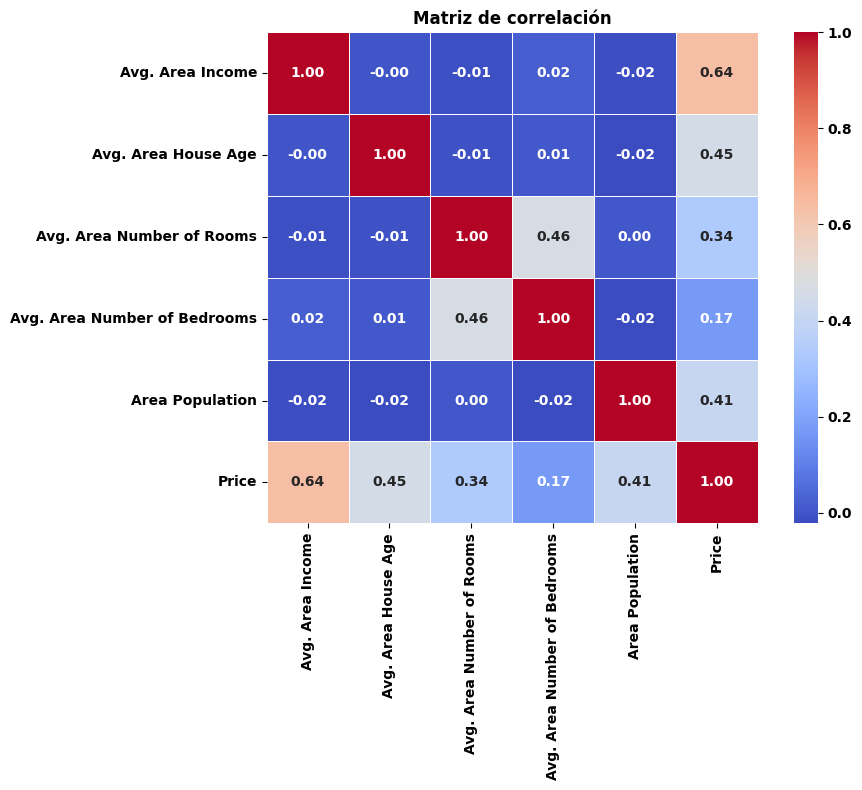

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df2.corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [7]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

In [8]:

# Split up the data into a training set
#random state es una vaor semilla para hacer la separaciion. Hace que cada vez que lo ejecutemos los conjuntos de entrenaiento y tes sean los mismos 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

#### 2. Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 2.1 Evaluamos el modelo

In [10]:
y_pred = rf.predict(X_test)
y_pred

array([1211807.51766476,  931997.15042243, 1683367.31993055, ...,
        499683.15326816, 1102186.0808286 , 1505449.6208243 ],
      shape=(2000,))

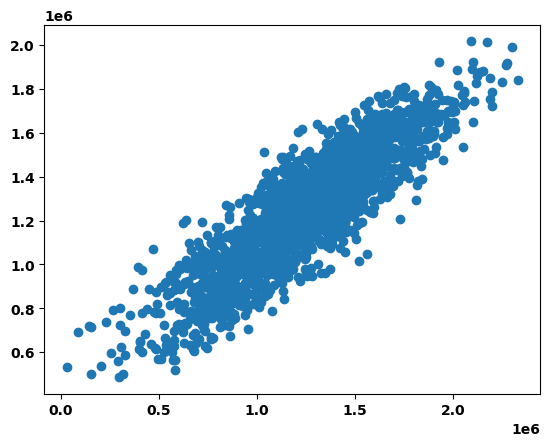

In [11]:
# y estimada vs y real
plt.scatter(y_test,y_pred)

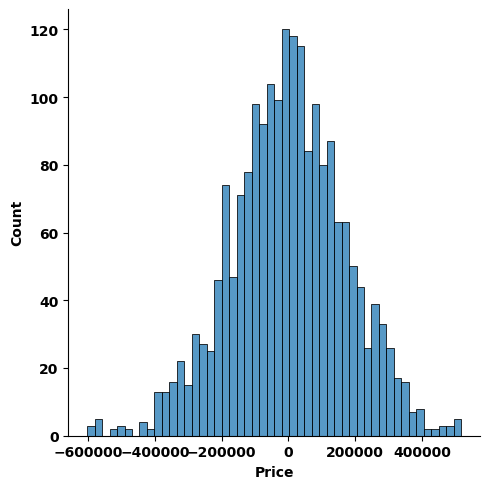

In [12]:
# histograma de residuales
sns.displot((y_test-y_pred),bins=50);

#### 2.3 Métricas de error   



**Mean Absolute Error** (MAE) es la media del valor absoluto de los errores:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) es la media de los cuadrados de los errores:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) es la raiz cuadradade los errores al cuadrado:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$


In [13]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 135282.8976585146
MSE: 29871932155.25472
RMSE: 172834.98533356815


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
r2_rf = r2_score(y_test, y_pred)
print("R^2:", r2_rf)

R^2: 0.764936870953132


#### 3. Modelo XGB Regressor  

In [15]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### 3.1 Evaluamos el modelo 

In [16]:
y_pred = xgb_model.predict(X_test)

In [17]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 91098.4303191718
MSE: 13009606574.59748
RMSE: 114059.66234649952


In [18]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2f}")


R² Score: 0.90


#### 4 LGBM regresión

In [19]:
from lightgbm import LGBMRegressor
lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### 4.1 Evaluamos el modelo

In [20]:
y_pred = lgbm_model.predict(X_test)

#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


MAE: 90887.98241776897
MSE: 13124398599.529285
RMSE: 114561.7676169903


In [21]:

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")


R² Score: 0.8967


#### 4.2 Optimizacion
Para optimizar el MSE

In [22]:
import optuna
# Función objetivo para Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse  # Queremos minimizar el error

# 🚀 Ejecutar la optimización
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# 📊 Resultados
print("Mejores hiperparámetros:")
print(study.best_params)

print(f"\nMejor MSE obtenido: {study.best_value:.4f}")


c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-17 19:38:55,075] A new study created in memory with name: no-name-e8871cc2-a662-4018-ba73-dc9dd4a7f6fe


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:55,184] Trial 0 finished with value: 14585528478.475273 and parameters: {'n_estimators': 156, 'learning_rate': 0.21418297485461513, 'max_depth': 7, 'subsample': 0.5644757833069374, 'colsample_bytree': 0.7374637438719682, 'reg_alpha': 1.8917832762189257, 'reg_lambda': 3.580565867026448}. Best is trial 0 with value: 14585528478.475273.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Foun

[I 2026-03-17 19:38:55,408] Trial 1 finished with value: 14132222194.095976 and parameters: {'n_estimators': 398, 'learning_rate': 0.12668951044240656, 'max_depth': 6, 'subsample': 0.9659889155589049, 'colsample_bytree': 0.6916959745505975, 'reg_alpha': 4.956819224225044, 'reg_lambda': 4.121037396507947}. Best is trial 1 with value: 14132222194.095976.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:55,543] Trial 2 finished with value: 12509005340.979889 and parameters: {'n_estimators': 276, 'learning_rate': 0.059053792888822475, 'max_depth': 4, 'subsample': 0.5333046544385843, 'colsample_bytree': 0.5683174037076466, 'reg_alpha': 4.037238006792452, 'reg_lambda': 0.8481969576555642}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:55,706] Trial 3 finished with value: 14498295072.68905 and parameters: {'n_estimators': 395, 'learning_rate': 0.2430033343030774, 'max_depth': 4, 'subsample': 0.652524551741704, 'colsample_bytree': 0.6851054813808293, 'reg_alpha': 2.8848447672681083, 'reg_lambda': 4.413601850271593}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:55,823] Trial 4 finished with value: 14196790169.665312 and parameters: {'n_estimators': 161, 'learning_rate': 0.1958150630243877, 'max_depth': 6, 'subsample': 0.7759892513507629, 'colsample_bytree': 0.8544090875075985, 'reg_alpha': 2.5598652695207353, 'reg_lambda': 1.160819988193818}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,102] Trial 5 finished with value: 13572539228.41772 and parameters: {'n_estimators': 294, 'learning_rate': 0.017877537832149633, 'max_depth': 9, 'subsample': 0.8962854208945099, 'colsample_bytree': 0.8706500534393848, 'reg_alpha': 0.9281672936462804, 'reg_lambda': 1.0268586672671387}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,259] Trial 6 finished with value: 12940568803.827291 and parameters: {'n_estimators': 243, 'learning_rate': 0.02969072770464913, 'max_depth': 5, 'subsample': 0.6650897875484113, 'colsample_bytree': 0.6243921531465516, 'reg_alpha': 1.684328609079126, 'reg_lambda': 1.7295483940620027}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,397] Trial 7 finished with value: 15410880889.526247 and parameters: {'n_estimators': 150, 'learning_rate': 0.28697963845592395, 'max_depth': 10, 'subsample': 0.6161753396839915, 'colsample_bytree': 0.7053475927231126, 'reg_alpha': 2.8107094190437456, 'reg_lambda': 4.3203246358579515}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,538] Trial 8 finished with value: 14088728481.395512 and parameters: {'n_estimators': 239, 'learning_rate': 0.1733799615373209, 'max_depth': 5, 'subsample': 0.9991927955190121, 'colsample_bytree': 0.7959406675316549, 'reg_alpha': 1.26303732477185, 'reg_lambda': 2.339511569063084}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,740] Trial 9 finished with value: 13027502123.897738 and parameters: {'n_estimators': 224, 'learning_rate': 0.04783584055186659, 'max_depth': 6, 'subsample': 0.7673374130614783, 'colsample_bytree': 0.5163288338858545, 'reg_alpha': 1.1985042041566352, 'reg_lambda': 0.5267778765819836}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:56,883] Trial 10 finished with value: 12915861904.504927 and parameters: {'n_estimators': 339, 'learning_rate': 0.10228899329590058, 'max_depth': 3, 'subsample': 0.5009413524458126, 'colsample_bytree': 0.9869773901565793, 'reg_alpha': 4.363896380366911, 'reg_lambda': 0.008305038489701322}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-17 19:38:57,121] Trial 11 finished with value: 13156105628.776129 and parameters: {'n_estimators': 482, 'learning_rate': 0.10294714244294098, 'max_depth': 3, 'subsample': 0.5036239594689684, 'colsample_bytree': 0.9969020707368037, 'reg_alpha': 4.391700812879864, 'reg_lambda': 0.3125919446338563}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:57,302] Trial 12 finished with value: 12887427002.28723 and parameters: {'n_estimators': 344, 'learning_rate': 0.08752672978103654, 'max_depth': 3, 'subsample': 0.5175537863343953, 'colsample_bytree': 0.9806667651148421, 'reg_alpha': 3.8307071874788443, 'reg_lambda': 0.10090957619232854}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:57,497] Trial 13 finished with value: 12621103691.008297 and parameters: {'n_estimators': 338, 'learning_rate': 0.07005599416750997, 'max_depth': 4, 'subsample': 0.5694446823676438, 'colsample_bytree': 0.5121345679853763, 'reg_alpha': 3.5275236234749947, 'reg_lambda': 2.769451164098985}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:57,925] Trial 14 finished with value: 13308888832.526375 and parameters: {'n_estimators': 292, 'learning_rate': 0.062046474401434834, 'max_depth': 8, 'subsample': 0.7046797674387412, 'colsample_bytree': 0.5021982163850868, 'reg_alpha': 0.14156950016304837, 'reg_lambda': 3.1465961410120613}. Best is trial 2 with value: 12509005340.979889.
[I 2026-03-17 19:38:58,128] Trial 15 finished with value: 13592006609.919373 and parameters: {'n_estimators': 460, 'learning_rate': 0.13647394683788222, 'max_depth': 4, 'subsample': 0.5880210240345858, 'colsample_bytree': 0.581513376357842, 'reg_alpha': 3.424904712145369, 'reg_lambda': 2.4581109887306174}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:58,311] Trial 16 finished with value: 12700775960.719307 and parameters: {'n_estimators': 404, 'learning_rate': 0.06971616018814708, 'max_depth': 4, 'subsample': 0.8426155465757703, 'colsample_bytree': 0.5781031810029229, 'reg_alpha': 3.533664076422539, 'reg_lambda': 3.1164842478028474}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:58,417] Trial 17 finished with value: 40772427129.62546 and parameters: {'n_estimators': 102, 'learning_rate': 0.014023832198672703, 'max_depth': 5, 'subsample': 0.70723966900822, 'colsample_bytree': 0.57820442209123, 'reg_alpha': 3.8974495996129304, 'reg_lambda': 1.8856971642764189}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:58,640] Trial 18 finished with value: 14591123328.284863 and parameters: {'n_estimators': 330, 'learning_rate': 0.15146564708646354, 'max_depth': 7, 'subsample': 0.563145339173593, 'colsample_bytree': 0.6383080737600577, 'reg_alpha': 3.0967166689437557, 'reg_lambda': 1.510206115083919}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:58,810] Trial 19 finished with value: 12516078879.501596 and parameters: {'n_estimators': 269, 'learning_rate': 0.05049872473925435, 'max_depth': 4, 'subsample': 0.6234249426002708, 'colsample_bytree': 0.5271789409486572, 'reg_alpha': 4.967360644368785, 'reg_lambda': 2.8983642607137585}. Best is trial 2 with value: 12509005340.979889.
[I 2026-03-17 19:38:58,970] Trial 20 finished with value: 13162290744.337088 and parameters: {'n_estimators': 215, 'learning_rate': 0.11638861508325377, 'max_depth': 5, 'subsample': 0.6462492015328425, 'colsample_bytree': 0.6193603384767846, 'reg_alpha': 4.874396602823538, 'reg_lambda': 4.958833997363353}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:38:59,145] Trial 21 finished with value: 12571733479.576706 and parameters: {'n_estimators': 268, 'learning_rate': 0.0483922796488879, 'max_depth': 4, 'subsample': 0.5611763072638223, 'colsample_bytree': 0.5415264065056641, 'reg_alpha': 4.260688081597232, 'reg_lambda': 2.9957897591681886}. Best is trial 2 with value: 12509005340.979889.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:59,297] Trial 22 finished with value: 12348154551.641766 and parameters: {'n_estimators': 264, 'learning_rate': 0.04883697700790383, 'max_depth': 3, 'subsample': 0.5472875668002327, 'colsample_bytree': 0.5649753774388311, 'reg_alpha': 4.421472805950232, 'reg_lambda': 3.7948804842596062}. Best is trial 22 with value: 12348154551.641766.
[I 2026-03-17 19:38:59,417] Trial 23 finished with value: 13632637968.670794 and parameters: {'n_estimators': 200, 'learning_rate': 0.03684772588422566, 'max_depth': 3, 'subsample': 0.6152749556745982, 'colsample_bytree': 0.5570893530195804, 'reg_alpha': 4.753381254681162, 'reg_lambda': 3.7284247698517623}. Best is trial 22 with value: 12348154551.641766.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Foun

[I 2026-03-17 19:38:59,559] Trial 24 finished with value: 12210899041.894829 and parameters: {'n_estimators': 268, 'learning_rate': 0.08405278348694276, 'max_depth': 3, 'subsample': 0.5406505147395811, 'colsample_bytree': 0.6532149913863594, 'reg_alpha': 4.199125157791666, 'reg_lambda': 3.539275557982866}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:38:59,697] Trial 25 finished with value: 12361935340.961082 and parameters: {'n_estimators': 184, 'learning_rate': 0.08029730655414576, 'max_depth': 3, 'subsample': 0.5330036403214821, 'colsample_bytree': 0.6468594175444231, 'reg_alpha': 4.006798632017375, 'reg_lambda': 3.5505052621246262}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:38:59,811] Trial 26 finished with value: 12271253040.6388 and parameters: {'n_estimators': 183, 'learning_rate': 0.10427643021440516, 'max_depth': 3, 'subsample': 0.6976260378715116, 'colsample_bytree': 0.6540656789473673, 'reg_alpha': 4.553925996555637, 'reg_lambda': 3.676281280832017}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:38:59,912] Trial 27 finished with value: 12924277613.49602 and parameters: {'n_estimators': 132, 'learning_rate': 0.09892862606246398, 'max_depth': 3, 'subsample': 0.8798583231678384, 'colsample_bytree': 0.7671258834553849, 'reg_alpha': 4.453564372961262, 'reg_lambda': 

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:00,073] Trial 28 finished with value: 12530295196.694733 and parameters: {'n_estimators': 179, 'learning_rate': 0.15541305332743838, 'max_depth': 3, 'subsample': 0.7009018012299395, 'colsample_bytree': 0.6667125389410441, 'reg_alpha': 3.191648828132477, 'reg_lambda': 3.942401902339113}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:00,445] Trial 29 finished with value: 13788812028.118023 and parameters: {'n_estimators': 243, 'learning_rate': 0.11657876843646726, 'max_depth': 8, 'subsample': 0.8091351548846111, 'colsample_bytree': 0.749602174595919, 'reg_alpha': 2.2407808041378443, 'reg_lambda': 3.437599721358092}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:00,678] Trial 30 finished with value: 13351927189.24857 and parameters: {'n_estimators': 316, 'learning_rate': 0.08754746551953382, 'max_depth': 5, 'subsample': 0.588073851310076, 'colsample_bytree': 0.7173090777646355, 'reg_alpha': 3.725525076714578, 'reg_lambda': 4.598164307436081}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:00,784] Trial 31 finished with value: 12300514073.890064 and parameters: {'n_estimators': 193, 'learning_rate': 0.08160604322064671, 'max_depth': 3, 'subsample': 0.5328952372851078, 'colsample_bytree': 0.6482897171440043, 'reg_alpha': 4.631125326180939, 'reg_lambda': 3.525716618454845}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:00,901] Trial 32 finished with value: 12389894117.511988 and parameters: {'n_estimators': 196, 'learning_rate': 0.13807547381762697, 'max_depth': 3, 'subsample': 0.5436437015449368, 'colsample_bytree': 0.6077024839685957, 'reg_alpha': 4.63370042721717, 'reg_lambda': 3.849233230108892}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:01,007] Trial 33 finished with value: 12890956695.888466 and parameters: {'n_estimators': 111, 'learning_rate': 0.07533766824255449, 'max_depth': 4, 'subsample': 0.5926894117016679, 'colsample_bytree': 0.6662991244841653, 'reg_alpha': 4.186949357202995, 'reg_lambda': 3.364452999314559}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:01,117] Trial 34 finished with value: 16158011196.574673 and parameters: {'n_estimators': 162, 'learning_rate': 0.032900575870385744, 'max_depth': 3, 'subsample': 0.6743181063703014, 'colsample_bytree': 0.5987404725356904, 'reg_alpha': 4.647016382732166, 'reg_lambda': 3.9956825817899584}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:01,307] Trial 35 finished with value: 12800846925.173393 and parameters: {'n_estimators': 258, 'learning_rate': 0.11617587166706875, 'max_depth': 4, 'subsample': 0.7364799001954223, 'colsample_bytree': 0.6821070096225719, 'reg_alpha': 4.5278076946452135, 'reg_lambda': 4.25833076093158}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:01,603] Trial 36 finished with value: 13523350351.355574 and parameters: {'n_estimators': 379, 'learning_rate': 0.17677159051962246, 'max_depth': 3, 'subsample': 0.5367957529323303, 'colsample_bytree': 0.7851338330504496, 'reg_alpha': 4.984633107613919, 'reg_lambda': 4.529464097528494}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000308 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:02,020] Trial 37 finished with value: 14031910928.134151 and parameters: {'n_estimators': 219, 'learning_rate': 0.23365279316116666, 'max_depth': 4, 'subsample': 0.6367262291746661, 'colsample_bytree': 0.7254722634662101, 'reg_alpha': 4.143755443628151, 'reg_lambda': 3.6196029855637826}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:02,427] Trial 38 finished with value: 13485674056.054132 and parameters: {'n_estimators': 290, 'learning_rate': 0.0966993493867775, 'max_depth': 6, 'subsample': 0.6766128958217641, 'colsample_bytree': 0.6485355946793326, 'reg_alpha': 3.706379930925757, 'reg_lambda': 3.3041181123992387}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:02,611] Trial 39 finished with value: 12963094740.791214 and parameters: {'n_estimators': 135, 'learning_rate': 0.060958024729333656, 'max_depth': 5, 'subsample': 0.5995898547111201, 'colsample_bytree': 0.6864351678399709, 'reg_alpha': 2.524440232341097, 'reg_lambda': 2.7580793981876877}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:02,838] Trial 40 finished with value: 13751456596.36157 and parameters: {'n_estimators': 171, 'learning_rate': 0.13028564104928758, 'max_depth': 10, 'subsample': 0.9376252691007378, 'colsample_bytree': 0.8400713174856383, 'reg_alpha': 4.030483525782666, 'reg_lambda': 4.616602003175991}. Best is trial 24 with value: 12210899041.894829.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:02,941] Trial 41 finished with value: 12292820322.949621 and parameters: {'n_estimators': 192, 'learning_rate': 0.08916462617144277, 'max_depth': 3, 'subsample': 0.5315648709935658, 'colsample_bytree': 0.6346339911887957, 'reg_alpha': 4.075624074040302, 'reg_lambda': 3.6236865971528207}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:03,058] Trial 42 finished with value: 14854138358.329195 and parameters: {'n_estimators': 230, 'learning_rate': 0.026758954617606218, 'max_depth': 3, 'subsample': 0.5518382891175196, 'colsample_bytree': 0.6048713171551205, 'reg_alpha': 4.581753104507987, 'reg_lambda': 4.149618779032036}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:03,154] Trial 43 finished with value: 12264579782.992262 and parameters: {'n_estimators': 203, 'learning_rate': 0.08772322588587876, 'max_depth': 3, 'subsample': 0.522729759826313, 'colsample_bytree': 0.5573138740273924, 'reg_alpha': 4.2380489947610664, 'reg_lambd

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:03,267] Trial 44 finished with value: 13158376264.493696 and parameters: {'n_estimators': 200, 'learning_rate': 0.11015451911697617, 'max_depth': 4, 'subsample': 0.5128048520595883, 'colsample_bytree': 0.7036770023061558, 'reg_alpha': 3.214274901551437, 'reg_lambda': 1.8322604669554436}. Best is trial 24 with value: 12210899041.894829.
[I 2026-03-17 19:39:03,356] Trial 45 finished with value: 12194166026.549677 and parameters: {'n_estimators': 207, 'learning_rate': 0.08727903281756519, 'max_depth': 3, 'subsample': 0.5229627126100401, 'colsample_bytree': 0.6646353005952923, 'reg_alpha': 4.27862723295968, 'reg_lambda': 2.058988096598939}. Best is trial 45 with value: 12194166026.549677.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:03,440] Trial 46 finished with value: 12467303298.318117 and parameters: {'n_estimators': 139, 'learning_rate': 0.09211469650367182, 'max_depth': 4, 'subsample': 0.5739139144321322, 'colsample_bytree': 0.6260849954417387, 'reg_alpha': 2.8683509297991048, 'reg_lambda': 1.4452571679462634}. Best is trial 45 with value: 12194166026.549677.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:03,599] Trial 47 finished with value: 14442551889.195484 and parameters: {'n_estimators': 214, 'learning_rate': 0.15115191619560958, 'max_depth': 7, 'subsample': 0.5007269760964964, 'colsample_bytree': 0.951138962221834, 'reg_alpha': 2.0971404552004573, 'reg_lambda': 2.188739607085145}. Best is trial 45 with value: 12194166026.549677.
[I 2026-03-17 19:39:03,694] Trial 48 finished with value: 12797860934.278448 and parameters: {'n_estimators': 245, 'learning_rate': 0.12367670838065023, 'max_depth': 3, 'subsample': 0.5186376135397096, 'colsample_bytree': 0.7338890745324326, 'reg_alpha': 4.212952199048071, 'reg_lambda': 2.05074602813172}. Best is trial 45 with value: 12194166026.549677.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:03,851] Trial 49 finished with value: 13052160432.7122 and parameters: {'n_estimators': 157, 'learning_rate': 0.0677643745861161, 'max_depth': 9, 'subsample': 0.7802825999937544, 'colsample_bytree': 0.6654098982237509, 'reg_alpha': 3.7039293310588888, 'reg_lambda': 2.4576397288063654}. Best is trial 45 with value: 12194166026.549677.


Mejores hiperparámetros:
{'n_estimators': 207, 'learning_rate': 0.08727903281756519, 'max_depth': 3, 'subsample': 0.5229627126100401, 'colsample_bytree': 0.6646353005952923, 'reg_alpha': 4.27862723295968, 'reg_lambda': 2.058988096598939}

Mejor MSE obtenido: 12194166026.5497


In [23]:
from sklearn.metrics import r2_score

#  Entrenar modelo con los mejores hiperparámetros encontrados
best_params = study.best_params
final_model = LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

# Predecir sobre el conjunto de test
y_pred = final_model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#  Calcular R²
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

#### Optimizamos R2

In [24]:
from sklearn.metrics import r2_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2  # Queremos maximizar R²
    
#  Ejecutar la optimización
study = optuna.create_study(direction='maximize')  # ¡Ahora maximizamos!
study.optimize(objective, n_trials=50)


#  Resultados
print("Mejores hiperparámetros:")
print(study.best_params)

print(f"\nMejor r2 obtenido: {study.best_value:.4f}")

[I 2026-03-17 19:39:04,154] A new study created in memory with name: no-name-040beead-7bfa-4e76-ae03-96f9e2014d03


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:04,361] Trial 0 finished with value: 0.8871402009242999 and parameters: {'n_estimators': 190, 'learning_rate': 0.02455306540251379, 'max_depth': 5, 'subsample': 0.7922322893859204, 'colsample_bytree': 0.7822745002035814, 'reg_alpha': 0.3250019552683503, 'reg_lambda': 2.6807393288863466}. Best is trial 0 with value: 0.8871402009242999.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:04,727] Trial 1 finished with value: 0.8700430665243886 and parameters: {'n_estimators': 373, 'learning_rate': 0.26016582659269993, 'max_depth': 7, 'subsample': 0.5435826994756217, 'colsample_bytree': 0.9326424329399023, 'reg_alpha': 4.0939077450215215, 'reg_lambda': 3.7666406560691246}. Best is trial 0 with value: 0.8871402009242999.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:04,925] Trial 2 finished with value: 0.8934814052634559 and parameters: {'n_estimators': 399, 'learning_rate': 0.12908146679379906, 'max_depth': 4, 'subsample': 0.71432970754047, 'colsample_bytree': 0.8580757771921117, 'reg_alpha': 2.2873650174473155, 'reg_lambda': 0.5974503401451065}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:05,394] Trial 3 finished with value: 0.8745544012762647 and parameters: {'n_estimators': 423, 'learning_rate': 0.20762277139447416, 'max_depth': 10, 'subsample': 0.536401694228336, 'colsample_bytree': 0.8843531422252373, 'reg_alpha': 2.7818081724048827, 'reg_lambda': 3.8000897932153426}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:05,751] Trial 4 finished with value: 0.8810277625638638 and parameters: {'n_estimators': 428, 'learning_rate': 0.15169917653907317, 'max_depth': 8, 'subsample': 0.8213510212557189, 'colsample_bytree': 0.772484669535656, 'reg_alpha': 4.484834647669389, 'reg_lambda': 0.15301169689473537}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:05,934] Trial 5 finished with value: 0.8723556083100387 and parameters: {'n_estimators': 220, 'learning_rate': 0.29359718762754133, 'max_depth': 7, 'subsample': 0.6699286665013573, 'colsample_bytree': 0.9316237313894917, 'reg_alpha': 0.1321329893343004, 'reg_lambda': 1.638216795120937}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:06,142] Trial 6 finished with value: 0.8761340181929518 and parameters: {'n_estimators': 234, 'learning_rate': 0.2361593689387791, 'max_depth': 8, 'subsample': 0.9502363302203218, 'colsample_bytree': 0.9786483402219122, 'reg_alpha': 1.0832504975441153, 'reg_lambda': 2.259204533994647}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:06,374] Trial 7 finished with value: 0.8756934054197695 and parameters: {'n_estimators': 439, 'learning_rate': 0.28358094103133125, 'max_depth': 5, 'subsample': 0.9118319535722375, 'colsample_bytree': 0.8671613255758199, 'reg_alpha': 0.21674267136995384, 'reg_lambda': 3.4690357865068315}. Best is trial 2 with value: 0.8934814052634559.



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

[I 2026-03-17 19:39:06,650] Trial 8 finished with value: 0.8763790279031365 and parameters: {'n_estimators': 301, 'learning_rate': 0.21144203792601649, 'max_depth': 9, 'subsample': 0.6309298728862086, 'colsample_bytree': 0.9173821848429607, 'reg_alpha': 2.974612521430054, 'reg_lambda': 4.179948140599609}. Best is trial 2 with value: 0.8934814052634559.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:06,908] Trial 9 finished with value: 0.8798117819419287 and parameters: {'n_estimators': 258, 'learning_rate': 0.18898146991213827, 'max_depth': 7, 'subsample': 0.8588545670773554, 'colsample_bytree': 0.9462839262110356, 'reg_alpha': 4.863550347481562, 'reg_lambda': 3.4419732157734453}. Best is trial 2 with value: 0.8934814052634559.
[I 2026-03-17 19:39:06,990] Trial 10 finished with value: 0.9012085834216036 and parameters: {'n_estimators': 102, 'learning_rate': 0.10199545820398534, 'max_depth': 3, 'subsample': 0.7125016155629602, 'colsample_bytree': 0.5735916691797788, 'reg_alpha': 1.759678111383762, 'reg_lambda': 0.3713101219761299}. Best is trial 10 with value: 0.9012085834216036.
[I 2026-03-17 19:39:07,059] Trial 11 finished with value: 0.9017330512639464 and parameters: {'n_estimators': 113, 'learning_rate': 0.09709301442710298, 'max_depth': 3, 'subsample': 0.7033984975160482, 'colsample_bytree': 0.5014182112029164, 'reg_alpha': 1.7208319334130262, 'reg_lambda

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:07,185] Trial 13 finished with value: 0.8896086656402231 and parameters: {'n_estimators': 100, 'learning_rate': 0.06765662580572532, 'max_depth': 3, 'subsample': 0.6207330067277067, 'colsample_bytree': 0.5183815863030697, 'reg_alpha': 1.3860268577659212, 'reg_lambda': 1.065889887695502}. Best is trial 11 with value: 0.9017330512639464.
[I 2026-03-17 19:39:07,310] Trial 14 finished with value: 0.8988345463164285 and parameters: {'n_estimators': 172, 'learning_rate': 0.10028110061962175, 'max_depth': 5, 'subsample': 0.6902223604741697, 'colsample_bytree': 0.6068378167924101, 'reg_alpha': 1.8766607282037566, 'reg_lambda': 0.04514937719879836}. Best is trial 11 with value: 0.9017330512639464.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:07,423] Trial 15 finished with value: 0.8898243327179111 and parameters: {'n_estimators': 151, 'learning_rate': 0.0379867485443367, 'max_depth': 4, 'subsample': 0.7655758731307951, 'colsample_bytree': 0.6092839898973388, 'reg_alpha': 3.33329145211582, 'reg_lambda': 4.9466046915504815}. Best is trial 11 with value: 0.9017330512639464.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:07,610] Trial 16 finished with value: 0.8991585298546478 and parameters: {'n_estimators': 496, 'learning_rate': 0.12440426852905097, 'max_depth': 3, 'subsample': 0.5960363004202958, 'colsample_bytree': 0.5922111265262701, 'reg_alpha': 0.9448207868702658, 'reg_lambda': 1.6233572602642228}. Best is trial 11 with value: 0.9017330512639464.
[I 2026-03-17 19:39:07,769] Trial 17 finished with value: 0.9027983820444486 and parameters: {'n_estimators': 308, 'learning_rate': 0.062079585245731025, 'max_depth': 4, 'subsample': 0.9981634670273168, 'colsample_bytree': 0.6970480049212259, 'reg_alpha': 2.2822268038894107, 'reg_lambda': 0.7484702546222068}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:08,052] Trial 18 finished with value: 0.9015323594823722 and parameters: {'n_estimators': 336, 'learning_rate': 0.05777396573792987, 'max_depth': 4, 'subsample': 0.9867166772718948, 'colsample_bytree': 0.6726034197060865, 'reg_alpha': 3.510666907771702, 'reg_lambda': 0.9064678923492676}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:08,265] Trial 19 finished with value: 0.8843908143394261 and parameters: {'n_estimators': 271, 'learning_rate': 0.16048307798674605, 'max_depth': 6, 'subsample': 0.8837682820620104, 'colsample_bytree': 0.7025934739101781, 'reg_alpha': 2.4783705311786806, 'reg_lambda': 1.5799881643721905}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:08,570] Trial 20 finished with value: 0.8837675425245455 and parameters: {'n_estimators': 328, 'learning_rate': 0.01423697478145483, 'max_depth': 6, 'subsample': 0.8503790417948222, 'colsample_bytree': 0.689801268760653, 'reg_alpha': 0.8403158040816763, 'reg_lambda': 2.583689450568051}. Best is trial 17 with value: 0.9027983820444486.
[I 2026-03-17 19:39:08,753] Trial 21 finished with value: 0.9014446527317135 and parameters: {'n_estimators': 354, 'learning_rate': 0.057001136581978876, 'max_depth': 4, 'subsample': 0.9915465705421943, 'colsample_bytree': 0.6623116061503725, 'reg_alpha': 3.683571491266787, 'reg_lambda': 0.7764770400870802}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:08,926] Trial 22 finished with value: 0.8987748159102369 and parameters: {'n_estimators': 305, 'learning_rate': 0.05943224643065745, 'max_depth': 4, 'subsample': 0.9999970463293241, 'colsample_bytree': 0.7220787331309415, 'reg_alpha': 3.4301912116151967, 'reg_lambda': 1.1164583542274142}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:09,180] Trial 23 finished with value: 0.8961327784110668 and parameters: {'n_estimators': 343, 'learning_rate': 0.08334553626617887, 'max_depth': 5, 'subsample': 0.937600235365774, 'colsample_bytree': 0.6356078042331528, 'reg_alpha': 2.269388238020795, 'reg_lambda': 2.1448745801125066}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:09,334] Trial 24 finished with value: 0.8996031998000875 and parameters: {'n_estimators': 261, 'learning_rate': 0.049906306537809246, 'max_depth': 4, 'subsample': 0.9599078103288348, 'colsample_bytree': 0.8109660106529358, 'reg_alpha': 2.9636933549650126, 'reg_lambda': 0.5229556770318036}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:09,469] Trial 25 finished with value: 0.9013315781034335 and parameters: {'n_estimators': 318, 'learning_rate': 0.12225544235573907, 'max_depth': 3, 'subsample': 0.9083668120125482, 'colsample_bytree': 0.570369223644688, 'reg_alpha': 3.8925965961675972, 'reg_lambda': 1.3254445026070352}. Best is trial 17 with value: 0.9027983820444486.
[I 2026-03-17 19:39:09,620] Trial 26 finished with value: 0.8996056852411444 and parameters: {'n_estimators': 283, 'learning_rate': 0.0836522438123421, 'max_depth': 4, 'subsample': 0.8035910986428965, 'colsample_bytree': 0.5403112126180902, 'reg_alpha': 2.0506161703340977, 'reg_lambda': 0.0006918151348136448}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:09,868] Trial 27 finished with value: 0.896584879891596 and parameters: {'n_estimators': 374, 'learning_rate': 0.02441094040195048, 'max_depth': 6, 'subsample': 0.7681525934311525, 'colsample_bytree': 0.7343989653033138, 'reg_alpha': 2.7983181969073256, 'reg_lambda': 0.8493418564142372}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:10,147] Trial 28 finished with value: 0.8949791069735487 and parameters: {'n_estimators': 218, 'learning_rate': 0.14463436117789175, 'max_depth': 5, 'subsample': 0.9762606058484297, 'colsample_bytree': 0.6475559571590567, 'reg_alpha': 1.331095277325733, 'reg_lambda': 1.9941240145960293}. Best is trial 17 with value: 0.9027983820444486.
[I 2026-03-17 19:39:10,261] Trial 29 finished with value: 0.8896038772380109 and parameters: {'n_estimators': 191, 'learning_rate': 0.03681392809487544, 'max_depth': 3, 'subsample': 0.9325870216167254, 'colsample_bytree': 0.8130113958594207, 'reg_alpha': 3.286789304159681, 'reg_lambda': 0.6125696227120546}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:10,571] Trial 30 finished with value: 0.8923056691642082 and parameters: {'n_estimators': 462, 'learning_rate': 0.1098779071573461, 'max_depth': 5, 'subsample': 0.8808556186939446, 'colsample_bytree': 0.6748599966305382, 'reg_alpha': 0.49822214138444365, 'reg_lambda': 3.0229614455042295}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:11,032] Trial 31 finished with value: 0.9006533039618634 and parameters: {'n_estimators': 352, 'learning_rate': 0.06708900121084402, 'max_depth': 4, 'subsample': 0.9972426894561636, 'colsample_bytree': 0.6608665820651812, 'reg_alpha': 3.8017194214323013, 'reg_lambda': 0.8667934112222493}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:11,405] Trial 32 finished with value: 0.8996929727873321 and parameters: {'n_estimators': 380, 'learning_rate': 0.039875861542142024, 'max_depth': 4, 'subsample': 0.9869248834682618, 'colsample_bytree': 0.7561850145790372, 'reg_alpha': 4.303716207295047, 'reg_lambda': 0.3585508182202034}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:11,590] Trial 33 finished with value: 0.9009192739191166 and parameters: {'n_estimators': 348, 'learning_rate': 0.07139257345422373, 'max_depth': 3, 'subsample': 0.9577116541124758, 'colsample_bytree': 0.8015470953425329, 'reg_alpha': 3.637562662932974, 'reg_lambda': 0.7750291706162674}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:11,974] Trial 34 finished with value: 0.8918092606178537 and parameters: {'n_estimators': 402, 'learning_rate': 0.013238077337115066, 'max_depth': 5, 'subsample': 0.915873986178452, 'colsample_bytree': 0.6362223647461752, 'reg_alpha': 2.5569617952870547, 'reg_lambda': 1.3497257677656778}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:12,203] Trial 35 finished with value: 0.8991085635255769 and parameters: {'n_estimators': 394, 'learning_rate': 0.054448016272418076, 'max_depth': 4, 'subsample': 0.5755844824954195, 'colsample_bytree': 0.7059872271001972, 'reg_alpha': 4.541638680419356, 'reg_lambda': 0.31552749575577654}. Best is trial 17 with value: 0.9027983820444486.
[I 2026-03-17 19:39:12,435] Trial 36 finished with value: 0.8911208172560907 and parameters: {'n_estimators': 330, 'learning_rate': 0.17409773739272716, 'max_depth': 4, 'subsample': 0.6575095175490744, 'colsample_bytree': 0.7588260815992708, 'reg_alpha': 2.1350667347039476, 'reg_lambda': 0.6437210137039298}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:12,828] Trial 37 finished with value: 0.8955719023255087 and parameters: {'n_estimators': 284, 'learning_rate': 0.07810142045782378, 'max_depth': 6, 'subsample': 0.735522058144191, 'colsample_bytree': 0.5670731734509397, 'reg_alpha': 4.002235833158645, 'reg_lambda': 1.8500417550375283}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:13,021] Trial 38 finished with value: 0.9013595902868988 and parameters: {'n_estimators': 360, 'learning_rate': 0.13753666818379, 'max_depth': 3, 'subsample': 0.8404495991355114, 'colsample_bytree': 0.543779981560761, 'reg_alpha': 2.5354906295617368, 'reg_lambda': 1.420042439531621}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:13,211] Trial 39 finished with value: 0.8957120961548151 and parameters: {'n_estimators': 139, 'learning_rate': 0.09297991133884685, 'max_depth': 10, 'subsample': 0.5031930797848007, 'colsample_bytree': 0.6743624686627576, 'reg_alpha': 3.1444986907472883, 'reg_lambda': 0.29920391861402557}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:13,488] Trial 40 finished with value: 0.891692192249733 and parameters: {'n_estimators': 225, 'learning_rate': 0.11355494104521648, 'max_depth': 8, 'subsample': 0.9726972561975064, 'colsample_bytree': 0.8410898607208693, 'reg_alpha': 1.4940695371957657, 'reg_lambda': 2.8924362511087125}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:13,685] Trial 41 finished with value: 0.9003000866489593 and parameters: {'n_estimators': 364, 'learning_rate': 0.13127872528442974, 'max_depth': 3, 'subsample': 0.8167914571337479, 'colsample_bytree': 0.5370009932342704, 'reg_alpha': 2.615094504356714, 'reg_lambda': 1.3601866008742773}. Best is trial 17 with value: 0.9027983820444486.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:14,019] Trial 42 finished with value: 0.902858821101751 and parameters: {'n_estimators': 417, 'learning_rate': 0.04709222800682812, 'max_depth': 3, 'subsample': 0.8419677981589134, 'colsample_bytree': 0.5414380389492995, 'reg_alpha': 3.6155070754036682, 'reg_lambda': 0.9978727635328233}. Best is trial 42 with value: 0.902858821101751.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:14,991] Trial 43 finished with value: 0.9014648009330989 and parameters: {'n_estimators': 448, 'learning_rate': 0.045232532634756545, 'max_depth': 4, 'subsample': 0.7858650930325306, 'colsample_bytree': 0.5019827556725124, 'reg_alpha': 3.6356884701675156, 'reg_lambda': 0.9826734670084872}. Best is trial 42 with value: 0.902858821101751.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:15,580] Trial 44 finished with value: 0.9036824822364375 and parameters: {'n_estimators': 449, 'learning_rate': 0.04365046725574915, 'max_depth': 3, 'subsample': 0.7874737440063072, 'colsample_bytree': 0.5010102535118678, 'reg_alpha': 4.115842887259928, 'reg_lambda': 1.0960612322116412}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 

[I 2026-03-17 19:39:15,925] Trial 45 finished with value: 0.9026214909049026 and parameters: {'n_estimators': 417, 'learning_rate': 0.030955144571812823, 'max_depth': 3, 'subsample': 0.7111439184237754, 'colsample_bytree': 0.5264819455837533, 'reg_alpha': 4.27372360023363, 'reg_lambda': 0.5438911822346927}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-17 19:39:16,228] Trial 46 finished with value: 0.9034252018712875 and parameters: {'n_estimators': 474, 'learning_rate': 0.02726471416164684, 'max_depth': 3, 'subsample': 0.7125168695038869, 'colsample_bytree': 0.5264218996904293, 'reg_alpha': 4.747048680792852, 'reg_lambda': 0.5173087071072949}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2026-03-17 19:39:16,613] Trial 47 finished with value: 0.9035688107279651 and parameters: {'n_estimators': 475, 'learning_rate': 0.028755316407809782, 'max_depth': 3, 'subsample': 0.7303715433292092, 'colsample_bytree': 0.5338413401334036, 'reg_alpha': 4.768682163605251, 'reg_lambda': 0.5811399823785417}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:16,871] Trial 48 finished with value: 0.9033784322976475 and parameters: {'n_estimators': 500, 'learning_rate': 0.02495714730633728, 'max_depth': 3, 'subsample': 0.6646957557910409, 'colsample_bytree': 0.5512600476901972, 'reg_alpha': 4.916974876184311, 'reg_lambda': 0.1729067106240889}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-17 19:39:17,115] Trial 49 finished with value: 0.9031042524239525 and parameters: {'n_estimators': 498, 'learning_rate': 0.022772600877145402, 'max_depth': 3, 'subsample': 0.6722137854906655, 'colsample_bytree': 0.5577359472015473, 'reg_alpha': 4.901341056603561, 'reg_lambda': 0.1848827210114321}. Best is trial 44 with value: 0.9036824822364375.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [25]:
from sklearn.metrics import r2_score

#  Entrenar modelo con los mejores hiperparámetros encontrados
best_params = study.best_params
final_model = LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

# Predecir sobre el conjunto de test
y_pred = final_model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#  Calcular R²
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

el R2 que da optuna tras su entrenamiento y el entrenamiento final con los parámetros que mejor ajsutan son ligeramente diferentes (0.0002) debido a componentes aleatorias del propio modelo LGBM.